In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, VotingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna

C:\Users\Sukhjot\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
df = pd.read_csv('../data/MF_simulation_DT_0.2.csv')

In [3]:
df.shape

(6000, 24)

In [4]:
df.head()

,batchID,time(hr),process_phase,scenario,pH,biomass_conc(g/L),substrate_conc(g/L),product_conc(g/L),acetate_conc(g/L),viability,...,agitation(rpm),ionic_strength(mol/L),TMP(cmHg),membrane_resistance(m1),flux(m/s),flux(LMH),power(W),filtration_time(hr),cumulative_eDNA(mg/L),cumulative_HCP(mg/L)
0,0,0.0,0,O2_limited,6.977670,0.118983,164.920421,0.001543,0.057413,0.953815,...,80.000000,0.153670,0.0,0.0,0.0,0.0,0.294912,0.0,0.0,0.0
1,0,0.2,0,O2_limited,6.977044,0.122950,164.912083,0.001889,0.059069,0.952639,...,80.554627,0.153904,0.0,0.0,0.0,0.0,0.301088,0.0,0.0,0.0
2,0,0.4,0,O2_limited,6.976423,0.129731,164.898592,0.002461,0.060714,0.951462,...,80.554627,0.153127,0.0,0.0,0.0,0.0,0.301088,0.0,0.0,0.0
3,0,0.6,0,O2_limited,6.975807,0.134429,164.888825,0.002867,0.062350,0.950285,...,80.554627,0.153658,0.0,0.0,0.0,0.0,0.301088,0.0,0.0,0.0
4,0,0.8,0,O2_limited,6.975195,0.137064,164.882762,0.003111,0.063976,0.949108,...,80.554627,0.154410,0.0,0.0,0.0,0.0,0.301088,0.0,0.0,0.0


In [5]:
features = [
    'biomass_conc(g/L)',
    'DO(%)',
    'kLa(hr1)',
    'viability',
    'ionic_strength(mol/L)',
    'power(W)',
    'agitation(rpm)',
    'gas_flow_rate(vvm)',
    'acetate_conc(g/L)',
    'filtration_time(hr)',
    'membrane_resistance(m1)'
]

target = 'TMP(cmHg)'

df_tmp = df[df['process_phase'] == 1].copy()
x = df_tmp[features]
y = df_tmp[target]

x.shape, y.shape

((2000, 11), (2000,))

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((1600, 11), (400, 11))

In [7]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test,preds)

    print("="*60)
    print(model_name)
    print("="*60)
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")
    print()
    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

In [ ]:
lr_model = LinearRegression()
lr_results = evaluate_model(lr_model, x_train_scaled, x_test_scaled, y_train, y_test, "Linear Regression")

Linear Regression
RMSE : 391.2908
MAE  : 278.8342
R²   : 0.9314



In [ ]:
def ridge_objective(trial):

    alpha = trial.suggest_float('alpha',1e-3,100,log=True)

    model = Ridge(alpha=alpha)
    scores = cross_val_score(model, x_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')
    return -scores.mean()


study_ridge = optuna.create_study(direction='minimize')

study_ridge.optimize(ridge_objective,n_trials=50)
print(study_ridge.best_params)

[I 2026-05-29 16:26:45,544] A new study created in memory with name: no-name-6b520d5a-673e-4420-9d54-04d08ab54605
[I 2026-05-29 16:26:45,788] Trial 0 finished with value: 445.37108578928235 and parameters: {'alpha': 0.5268219009432862}. Best is trial 0 with value: 445.37108578928235.
[I 2026-05-29 16:26:45,889] Trial 1 finished with value: 445.38796357830154 and parameters: {'alpha': 0.0055850782284539895}. Best is trial 0 with value: 445.37108578928235.
[I 2026-05-29 16:26:45,974] Trial 2 finished with value: 445.56441399919186 and parameters: {'alpha': 8.989510729619585}. Best is trial 0 with value: 445.37108578928235.
[I 2026-05-29 16:26:46,053] Trial 3 finished with value: 452.779245793659 and parameters: {'alpha': 69.5040115903887}. Best is trial 0 with value: 445.37108578928235.
[I 2026-05-29 16:26:46,139] Trial 4 finished with value: 445.38599807612184 and parameters: {'alpha': 0.05777407106667433}. Best is trial 0 with value: 445.37108578928235.
[I 2026-05-29 16:26:46,219] Tria

{'alpha': 2.16138572271692}


In [ ]:
ridge_model = Ridge(**study_ridge.best_params)
ridge_results = evaluate_model(ridge_model,x_train_scaled,x_test_scaled,y_train,y_test,"Ridge Regression")

Ridge Regression
RMSE : 391.3174
MAE  : 279.3341
R²   : 0.9314



In [ ]:
def lasso_objective(trial):

    alpha = trial.suggest_float('alpha',1e-4,10,log=True)

    model = Lasso(alpha=alpha)
    scores = cross_val_score(model,x_train_scaled,y_train,cv=5,scoring='neg_root_mean_squared_error')
    return -scores.mean()


study_lasso = optuna.create_study(direction='minimize')
study_lasso.optimize(lasso_objective,n_trials=50)
print(study_lasso.best_params)

[I 2026-05-29 16:26:50,865] A new study created in memory with name: no-name-6a19e51b-93d6-40f8-8db4-8d4a0f290701
[I 2026-05-29 16:26:51,019] Trial 0 finished with value: 445.40764006428856 and parameters: {'alpha': 0.9299476452878618}. Best is trial 0 with value: 445.40764006428856.
[I 2026-05-29 16:26:51,164] Trial 1 finished with value: 445.43719070916995 and parameters: {'alpha': 0.4807159086490624}. Best is trial 0 with value: 445.40764006428856.
C:\Users\Sukhjot\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.388e+07, tolerance: 3.188e+05
  model = cd_fast.enet_coordinate_descent(
C:\Users\Sukhjot\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might 

{'alpha': 0.00010040867100364069}


In [ ]:
lasso_model = Lasso(**study_lasso.best_params)
lasso_results = evaluate_model(lasso_model,x_train_scaled,x_test_scaled,y_train,y_test,"Lasso Regression")

C:\Users\Sukhjot\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.201e+08, tolerance: 3.902e+05
  model = cd_fast.enet_coordinate_descent(


Lasso Regression
RMSE : 391.2906
MAE  : 278.8342
R²   : 0.9314



In [ ]:
def svr_objective(trial):

    C = trial.suggest_float('C',0.1,100,log=True)

    epsilon = trial.suggest_float('epsilon',0.001,1)
    gamma = trial.suggest_categorical('gamma',['scale', 'auto'])

    model = SVR(C=C,epsilon=epsilon,gamma=gamma)

    scores = cross_val_score(model,x_train_scaled,y_train,cv=3,scoring='neg_root_mean_squared_error')
    return -scores.mean()


study_svr = optuna.create_study(direction='minimize')

study_svr.optimize(svr_objective,n_trials=50)
print(study_svr.best_params)

[I 2026-05-29 16:27:05,337] A new study created in memory with name: no-name-c0f5478c-884d-441f-838f-87ccf3d4fdf1
[I 2026-05-29 16:27:07,080] Trial 0 finished with value: 1047.3608723468926 and parameters: {'C': 7.419308541891988, 'epsilon': 0.567771229007434, 'gamma': 'scale'}. Best is trial 0 with value: 1047.3608723468926.
[I 2026-05-29 16:27:08,717] Trial 1 finished with value: 302.7149307035565 and parameters: {'C': 29.46958574014375, 'epsilon': 0.48599826618080855, 'gamma': 'scale'}. Best is trial 1 with value: 302.7149307035565.
[I 2026-05-29 16:27:10,368] Trial 2 finished with value: 1763.5628975673908 and parameters: {'C': 0.26478978320381275, 'epsilon': 0.04091103292986272, 'gamma': 'auto'}. Best is trial 1 with value: 302.7149307035565.
[I 2026-05-29 16:27:12,219] Trial 3 finished with value: 1481.7030235381342 and parameters: {'C': 2.611311983412047, 'epsilon': 0.5021738082800867, 'gamma': 'scale'}. Best is trial 1 with value: 302.7149307035565.
[I 2026-05-29 16:27:13,794] 

{'C': 99.24562161926994, 'epsilon': 0.11781634741090549, 'gamma': 'auto'}


In [ ]:
svr_model = SVR(**study_svr.best_params)
svr_results = evaluate_model(svr_model,x_train_scaled,x_test_scaled,y_train,y_test,"SVR")

SVR
RMSE : 172.0730
MAE  : 94.2384
R²   : 0.9867



In [ ]:
def dtr_objective(trial):

    params = {
        'max_depth': trial.suggest_int('max_depth',2,30),
        'min_samples_split': trial.suggest_int('min_samples_split',2,20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf',1,10)
    }

    model = DecisionTreeRegressor(**params)

    scores = cross_val_score(model,x_train,y_train,cv=5,scoring='neg_root_mean_squared_error')
    return -scores.mean()


study_dtr = optuna.create_study(direction='minimize')
study_dtr.optimize(dtr_objective,n_trials=50)
print(study_dtr.best_params)

[I 2026-05-29 16:28:20,926] A new study created in memory with name: no-name-0a231039-c0bf-4ed0-854d-3872b3da6807
[I 2026-05-29 16:28:21,351] Trial 0 finished with value: 94.61197706847119 and parameters: {'max_depth': 30, 'min_samples_split': 7, 'min_samples_leaf': 7}. Best is trial 0 with value: 94.61197706847119.
[I 2026-05-29 16:28:21,717] Trial 1 finished with value: 97.99058890946125 and parameters: {'max_depth': 19, 'min_samples_split': 17, 'min_samples_leaf': 8}. Best is trial 0 with value: 94.61197706847119.
[I 2026-05-29 16:28:21,992] Trial 2 finished with value: 121.97791975342439 and parameters: {'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 4}. Best is trial 0 with value: 94.61197706847119.
[I 2026-05-29 16:28:22,243] Trial 3 finished with value: 116.78078503412522 and parameters: {'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 3}. Best is trial 0 with value: 94.61197706847119.
[I 2026-05-29 16:28:22,569] Trial 4 finished with value: 103.782996

{'max_depth': 30, 'min_samples_split': 6, 'min_samples_leaf': 3}


In [ ]:
dtr_model = DecisionTreeRegressor(**study_dtr.best_params)
dtr_results = evaluate_model(dtr_model,x_train,x_test,y_train,y_test,"Decision Tree Regressor")

Decision Tree Regressor
RMSE : 82.6924
MAE  : 37.6392
R²   : 0.9969



In [ ]:
def rf_objective(trial):

    params = {

        'n_estimators': trial.suggest_int('n_estimators',50,300),
        'max_depth': trial.suggest_int('max_depth',3,30),
        'min_samples_split': trial.suggest_int('min_samples_split',2,20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf',1,10)
    }

    model = RandomForestRegressor(**params,random_state=42,n_jobs=-1)
    scores = cross_val_score(model,x_train,y_train,cv=3,scoring='neg_root_mean_squared_error')
    return -scores.mean()


study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(rf_objective,n_trials=50)
print(study_rf.best_params)

[I 2026-05-29 16:28:38,592] A new study created in memory with name: no-name-10141c2d-9f99-40a4-9eb1-473885fa805d
[I 2026-05-29 16:28:42,216] Trial 0 finished with value: 79.25572128660245 and parameters: {'n_estimators': 111, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 79.25572128660245.
[I 2026-05-29 16:28:48,669] Trial 1 finished with value: 205.39408888354674 and parameters: {'n_estimators': 283, 'max_depth': 3, 'min_samples_split': 14, 'min_samples_leaf': 7}. Best is trial 0 with value: 79.25572128660245.
[I 2026-05-29 16:28:51,009] Trial 2 finished with value: 204.17010743686288 and parameters: {'n_estimators': 80, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 0 with value: 79.25572128660245.
[I 2026-05-29 16:28:52,780] Trial 3 finished with value: 100.22029502958715 and parameters: {'n_estimators': 62, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 7}. Best is trial 0 with value: 79.255

{'n_estimators': 249, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 1}


In [ ]:
rf_model = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_results = evaluate_model(rf_model, x_train, x_test, y_train, y_test, "Random Forest")

Random Forest
RMSE : 66.9996
MAE  : 32.5464
R²   : 0.9980



In [ ]:
def xgb_objective(trial):

    params = {

        'n_estimators': trial.suggest_int('n_estimators',100,500),
        'max_depth': trial.suggest_int('max_depth',3,12),
        'learning_rate': trial.suggest_float('learning_rate',0.01,0.3),
        'subsample': trial.suggest_float('subsample',0.5,1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree',0.5,1.0)
    }

    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model,x_train,y_train,cv=3,scoring='neg_root_mean_squared_error')
    return -scores.mean()


study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(xgb_objective,n_trials=50)
print(study_xgb.best_params)

[I 2026-05-29 16:32:53,611] A new study created in memory with name: no-name-4c1b77bb-01c1-4a32-98c5-30c4ed21a8f2
[I 2026-05-29 16:33:04,239] Trial 0 finished with value: 67.04110741094432 and parameters: {'n_estimators': 122, 'max_depth': 11, 'learning_rate': 0.2928906487435426, 'subsample': 0.7428840532387818, 'colsample_bytree': 0.8492016424996165}. Best is trial 0 with value: 67.04110741094432.
[I 2026-05-29 16:33:15,871] Trial 1 finished with value: 61.01844899690192 and parameters: {'n_estimators': 481, 'max_depth': 12, 'learning_rate': 0.2731295989010868, 'subsample': 0.9903981217166054, 'colsample_bytree': 0.8626552759977483}. Best is trial 1 with value: 61.01844899690192.
[I 2026-05-29 16:33:30,635] Trial 2 finished with value: 59.42048921978377 and parameters: {'n_estimators': 472, 'max_depth': 11, 'learning_rate': 0.23709571800835258, 'subsample': 0.8458656517379884, 'colsample_bytree': 0.9881762970082046}. Best is trial 2 with value: 59.42048921978377.
[I 2026-05-29 16:33:3

{'n_estimators': 391, 'max_depth': 5, 'learning_rate': 0.17033022409977835, 'subsample': 0.8767028209409709, 'colsample_bytree': 0.8226227002071487}


In [ ]:
xgb_model = XGBRegressor(**study_xgb.best_params,random_state=42,n_jobs=-1)
xgb_results = evaluate_model(xgb_model, x_train, x_test, y_train, y_test, "XGBoost")

XGBoost
RMSE : 34.6648
MAE  : 18.6831
R²   : 0.9995



In [ ]:
voting_model = VotingRegressor([('rf', rf_model),('xgb', xgb_model),('svr', svr_model)])
voting_results = evaluate_model(voting_model, x_train, x_test, y_train, y_test, "Voting Regressor")

Voting Regressor
RMSE : 561.8167
MAE  : 369.0349
R²   : 0.8585



In [ ]:
stacking_model = StackingRegressor(estimators=[('rf', rf_model),('xgb', xgb_model),('svr', svr_model)],final_estimator=LinearRegression(),passthrough=True,n_jobs=-1)
stacking_results = evaluate_model(stacking_model,x_train,x_test,y_train,y_test,"Stacking Regressor")

Stacking Regressor
RMSE : 454.8283
MAE  : 305.5363
R²   : 0.9073



In [ ]:
results_df = pd.DataFrame([
    lr_results,
    ridge_results,
    lasso_results,
    svr_results,
    dtr_results,
    rf_results,
    xgb_results,
    voting_results,
    stacking_results
])

results_df = results_df.sort_values('R2',ascending=False)
display(results_df)

,Model,RMSE,MAE,R2
6,XGBoost,34.664770,18.683066,0.999461
5,Random Forest,66.999579,32.546413,0.997988
4,Decision Tree Regressor,82.692359,37.639243,0.996935
3,SVR,172.073039,94.238356,0.986726
2,Lasso Regression,391.290604,278.834194,0.931362
0,Linear Regression,391.290842,278.834162,0.931362
1,Ridge Regression,391.317357,279.334074,0.931353
8,Stacking Regressor,454.828336,305.536294,0.907262
7,Voting Regressor,561.816670,369.034888,0.858501


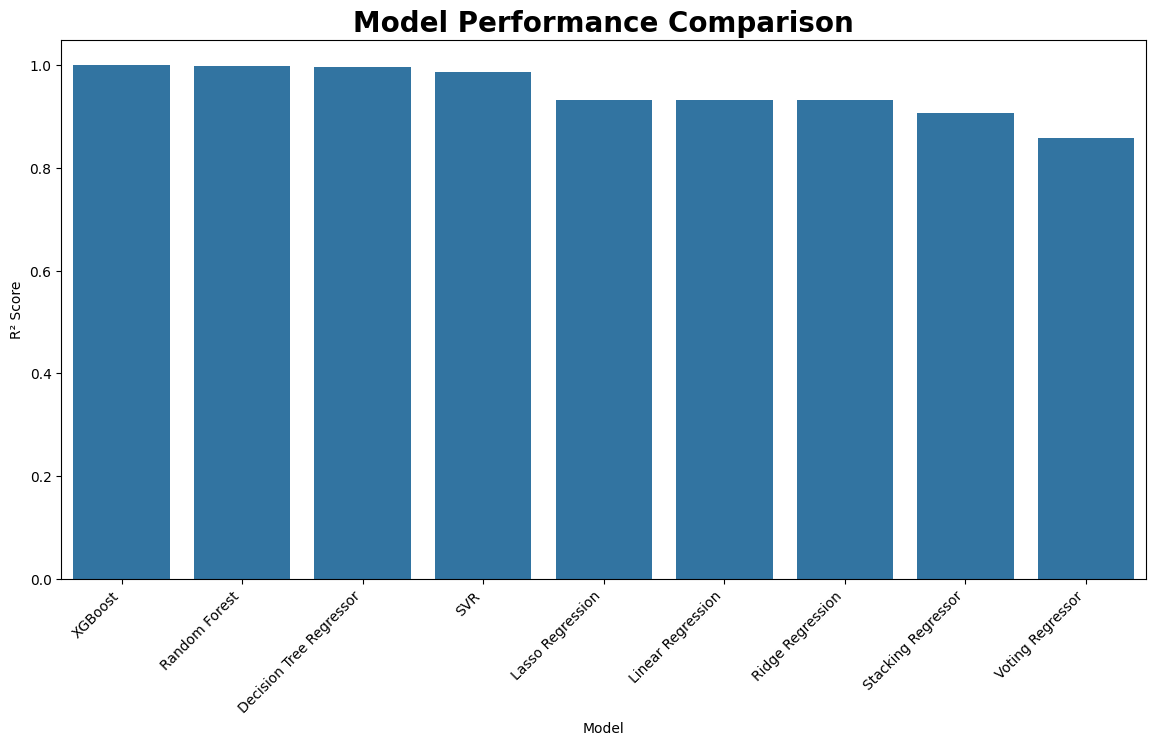

In [ ]:
import seaborn as sns
plt.figure(figsize=(14,7))
sns.barplot(data=results_df,x='Model',y='R2')

plt.xticks(rotation=45,ha='right')
plt.title("Model Performance Comparison",fontsize=20,fontweight='bold')
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.show()

,Feature,Importance
10,membrane_resistance(m1),0.866447
9,filtration_time(hr),0.052373
5,power(W),0.045144
3,viability,0.025501
2,kLa(hr1),0.005304
7,gas_flow_rate(vvm),0.002996
0,biomass_conc(g/L),0.001279
6,agitation(rpm),0.000475
8,acetate_conc(g/L),0.000390
4,ionic_strength(mol/L),0.000090


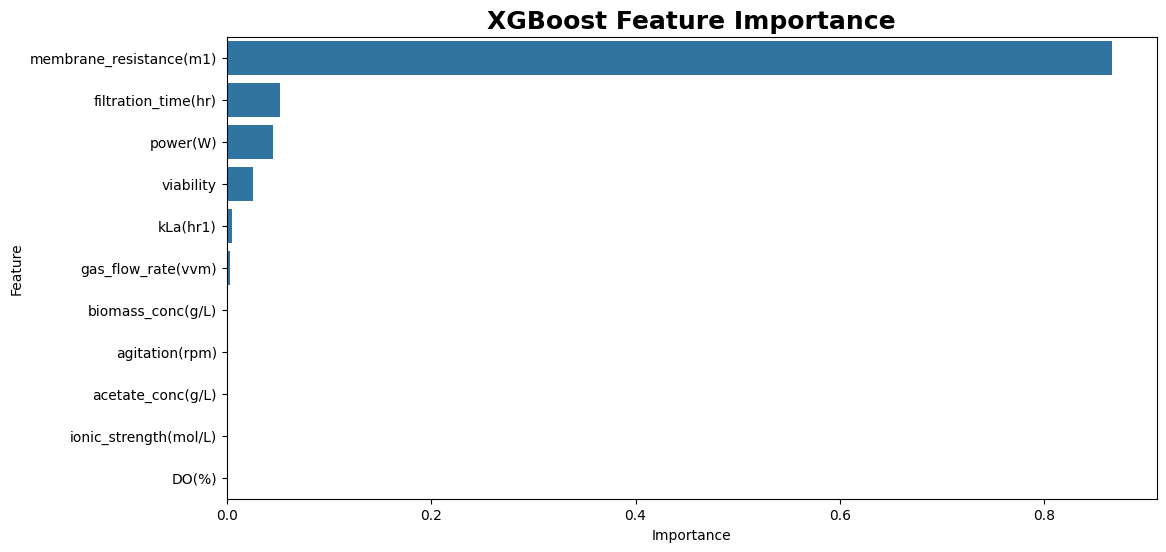

In [ ]:
importance_df = pd.DataFrame({'Feature': features,'Importance': xgb_model.feature_importances_})

importance_df = importance_df.sort_values('Importance',ascending=False)
display(importance_df)
plt.figure(figsize=(12,6))

sns.barplot(data=importance_df,x='Importance',y='Feature')
plt.title("XGBoost Feature Importance",fontsize=18,fontweight='bold')
plt.show()